# 0. 풀이 순서 정리

문제처리 방식

1. 미션 정의 및 환경설정
2. 기본 데이터 입력 및 데이터 탐색 및 분석 (EDA)
3. 전처리 및 데이터 파이프라인 구축 (Preprocessing & Data Pipeline)
4. 모델링 및 학습 (Modeling & Training)
5. 결과 시각화 (Feature Importance)
6. 성능 평가 및 최종 제출 (Performance Evaluation & Submission)

# 1-1. 미션 정의 및 환경설정

### 🎯 Mission: 축구 영상 분할을 위한 U-Net 기반 Semantic Segmentation

---

##### 📘 미션 소개

이번 미션에서는 **U-Net**을 이용해 축구 경기 영상 속 다양한 객체를 **픽셀 단위로 분할 (Semantic Segmentation)** 하는 과제를 수행합니다.  
실제 경기 장면 이미지를 기반으로 각 픽셀이 어떤 클래스에 속하는지 예측하는 모델을 직접 설계하고 학습해 보세요.

---

##### ⚽ 데이터 소개

**데이터 링크:** Football (Semantic Segmentation)

###### 📂 데이터 구성
본 데이터셋은 **UEFA 슈퍼컵 2017 (레알 마드리드 vs 맨체스터 유나이티드)** 경기의 하이라이트 영상을 기반으로 수집된 축구 경기 장면으로 구성되어 있습니다.

- 총 **100장**의 프레임 사용  
- 매 **12번째 프레임**을 추출하였으며, 흐릿한 장면이나 이상치는 일부 대체되었습니다.  
- **총 11개의 클래스**가 포함되어 있습니다.

###### 🏷 클래스 목록
| 번호 | 클래스명 | 설명 |
|------|-----------|------|
| 1 | Goal Bar | 골대 |
| 2 | Referee | 심판 |
| 3 | Advertisement | 광고판 |
| 4 | Ground | 잔디 |
| 5 | Ball | 축구공 |
| 6 | Coaches & Officials | 코칭 스태프 및 심판진 |
| 7 | Audience | 관중 |
| 8 | Goalkeeper A | 팀 A 골키퍼 |
| 9 | Goalkeeper B | 팀 B 골키퍼 |
| 10 | Team A | 팀 A 선수 |
| 11 | Team B | 팀 B 선수 |

---

##### 📑 제출 안내

**제출 파일명:**  
`08_{팀명}_{성함}.ipynb`

###### ✅ 제출 내용
1. **분석 과정 및 결과**  
   - 데이터 로드 및 전처리  
   - 모델 학습  
   - 예측 및 시각화  
   - 성능 평가  

2. **마크다운을 활용한 상세 설명**  
   - 각 코드 셀의 의도, 알고리즘, 함수 설명 등을 마크다운으로 정리  
   - 코드와 결과를 한눈에 이해할 수 있도록 구성  

3. **모델 성능 평가**  
   - Cross Entropy Loss, Dice Loss 등의 지표 활용  
   - 학습용(train) / 테스트용(test) 데이터 분할 후 테스트 세트 결과 포함  
   - 최종 학습된 모델과 시각화 결과 제시  

---

##### 🧠 참고 사항

- **Baseline 코드 링크:** Baseline Code  
- Baseline 코드는 시작점으로만 참고하세요.  
  직접 아이디어를 더해 성능을 향상시키는 것이 핵심입니다.  

---

##### 🚀 모델 성능 개선 팁

###### 1️⃣ 데이터 증강 (Data Augmentation)
축구 경기 영상은 조명, 환경, 유니폼 색상 등 다양한 변수가 존재합니다.  
다음과 같은 증강 기법을 적용하면 모델의 일반화 성능을 높일 수 있습니다.

- `Random Crop`  
- `Horizontal Flip`  
- `Color Jitter`

---

###### 2️⃣ 하이퍼파라미터 튜닝 (Hyperparameter Tuning)
모델 성능은 학습 설정에 크게 영향을 받습니다.  
다양한 조합을 시도해 최적의 값을 찾아보세요.

- **Learning Rate (학습률)**  
- **Batch Size (배치 크기)**  
- **Epochs (훈련 반복 횟수)**

---

###### 3️⃣ 모델 구조 변경 (Model Architecture)
기본 U-Net 구조 외에도, 성능을 향상시킬 수 있는 다양한 변형 모델을 시도해 볼 수 있습니다.

- **U-Net++**  
- **Attention U-Net**  

---

##### 🎯 최종 목표
> 축구 경기 장면 내 각 픽셀의 클래스를 정확히 분할하고,  
> 학습된 모델의 성능을 시각적으로 명확하게 제시하세요.


# 1-2. 미션설정 및 환경설정

In [ ]:
# --- 기본 도구 ---
import os                 # OS 기능, 경로 관리
import random             # 무작위 작업
from glob import glob      # 패턴으로 파일 경로 찾기
import numpy as np         # 숫자, 행렬 계산
from PIL import Image      # 이미지 파일 열기, 다루기

# --- 시각화 ---
import matplotlib.pyplot as plt # 그림 그리기

# --- PyTorch ---
import torch
import torch.nn as nn                  # 신경망 부품들 (레이어, 손실함수 등)
from torch.utils.data import Dataset, DataLoader # 데이터 공급용
import torchvision.transforms as T     # 이미지 변환 도구

print("✅ 라이브러리 임포트 완료!")

✅ 라이브러리 임포트 완료!


In [ ]:
# 데이터가 저장된 기본 경로를 설정.
image_folder = './data/images'

In [ ]:
current_path = os.getcwd()
print(f"현재 작업 경로: {current_path}\n")

현재 작업 경로: /Users/moon/My Drive/00. MIT/07. Artifical Intelligence/250807_AI 강의/04. 스프린트 과제/01. Mission 8



In [ ]:
print(f"👀 현재 경로의 내용물: {os.listdir('.')}\n")

👀 현재 경로의 내용물: ['anaconda_projects', 'Untitled.ipynb', '08_2팀_정재문.ipynb', '.ipynb_checkpoints', 'data', 'archive (1).zip']



# 2. 기본 데이터 입력 및 데이터 탐색 및 분석 (EDA)

- 여기서 고민, Fuse 를 쓸것인가 Save를 쓸것인가?

      - 이에 제공된 Baseline은 Fuse를 사용함.

## 2-1) Fuse와 Save (이는 Chapter 1-2에 따로 표시)

In [ ]:
Save에서 발견할 수 있는 색상은 몇개?

import numpy as np
from tqdm import tqdm
import cv2
import os

# --- 이전에 정의된 변수들을 그대로 사용합니다 ---
mask_files = sorted([f for f in os.listdir(image_folder) if "save" in f])
total_colors = set()

print("모든 'save.png' 마스크 파일을 스캔하여 고유 색상을 찾습니다...")
# tqdm을 사용
for mask_file in tqdm(mask_files):
    mask_path = os.path.join(image_folder, mask_file)

    mask = cv2.imread(mask_path)     # 이미지를 BGR 순서로 읽습니다.
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)     # 분석을 위해 RGB 순서로 변환합니다.

    # 이미지를 (높이, 너비, 3)에서 (픽셀 수, 3) 형태로 변환합니다.
    # 이렇게 하면 각 픽셀의 RGB 값을 쉽게 분석할 수 있습니다.
    pixels = mask.reshape(-1, 3)

    # 현재 이미지에만 있는 고유한 색상들을 찾습니다.
    unique_colors_in_image = np.unique(pixels, axis=0)

    # 찾은 고유 색상들을 전체 저장소(total_colors)에 추가합니다.
    for color in unique_colors_in_image:
        total_colors.add(tuple(color))

# --- 최종 결과 출력 ---
print("\n" + "="*40)
print("## 스캔이 완료되었습니다! ##")
print(f"모든 'save.png' 파일에서 발견된 고유 색상의 총 개수: {len(total_colors)}개")
print("="*40)
print("\n발견된 색상 목록 (RGB 값):")
# 결과를 보기 좋게 정렬해서 출력합니다.
for color in sorted(list(total_colors)):
    print(color)

Object `몇개` not found.
모든 'save.png' 마스크 파일을 스캔하여 고유 색상을 찾습니다...


100%|███████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [02:29<00:00,  1.49s/it]


## 스캔이 완료되었습니다! ##
모든 'save.png' 파일에서 발견된 고유 색상의 총 개수: 503개

발견된 색상 목록 (RGB 값):
(np.uint8(0), np.uint8(0), np.uint8(0))
(np.uint8(0), np.uint8(0), np.uint8(15))
(np.uint8(0), np.uint8(0), np.uint8(30))
(np.uint8(0), np.uint8(0), np.uint8(45))
(np.uint8(0), np.uint8(0), np.uint8(60))
(np.uint8(0), np.uint8(0), np.uint8(75))
(np.uint8(0), np.uint8(0), np.uint8(90))
(np.uint8(0), np.uint8(0), np.uint8(105))
(np.uint8(0), np.uint8(0), np.uint8(120))
(np.uint8(0), np.uint8(0), np.uint8(135))
(np.uint8(0), np.uint8(0), np.uint8(150))
(np.uint8(0), np.uint8(0), np.uint8(165))
(np.uint8(0), np.uint8(0), np.uint8(180))
(np.uint8(0), np.uint8(0), np.uint8(195))
(np.uint8(0), np.uint8(0), np.uint8(210))
(np.uint8(0), np.uint8(0), np.uint8(225))
(np.uint8(0), np.uint8(0), np.uint8(240))
(np.uint8(0), np.uint8(0), np.uint8(255))
(np.uint8(0), np.uint8(1), np.uint8(14))
(np.uint8(0), np.uint8(1), np.uint8(29))
(np.uint8(0), np.uint8(1), np.uint8(44))
(np.uint8(0), np.uint8(1), np.uint8(59))
(np.uin

In [ ]:
# Fuse에서 발견할 수 있는 고유 색상은 몇개?

import numpy as np
from tqdm import tqdm
import cv2
import os

# --- 이전에 정의된 변수들을 그대로 사용합니다 ---
mask_files = sorted([f for f in os.listdir(image_folder) if "fuse" in f])
total_colors = set()

print("모든 'save.png' 마스크 파일을 스캔하여 고유 색상을 찾습니다...")
# tqdm을 사용
for mask_file in tqdm(mask_files):
    mask_path = os.path.join(image_folder, mask_file)

    mask = cv2.imread(mask_path)     # 이미지를 BGR 순서로 읽습니다.
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)     # 분석을 위해 RGB 순서로 변환합니다.

    # 이미지를 (높이, 너비, 3)에서 (픽셀 수, 3) 형태로 변환합니다.
    # 이렇게 하면 각 픽셀의 RGB 값을 쉽게 분석할 수 있습니다.
    pixels = mask.reshape(-1, 3)

    # 현재 이미지에만 있는 고유한 색상들을 찾습니다.
    unique_colors_in_image = np.unique(pixels, axis=0)

    # 찾은 고유 색상들을 전체 저장소(total_colors)에 추가합니다.
    for color in unique_colors_in_image:
        total_colors.add(tuple(color))

# --- 최종 결과 출력 ---
print("\n" + "="*40)
print("## 스캔이 완료되었습니다! ##")
print(f"모든 'fuse.png' 파일에서 발견된 고유 색상의 총 개수: {len(total_colors)}개")
print("="*40)
print("\n발견된 색상 목록 (RGB 값):")
# 결과를 보기 좋게 정렬해서 출력합니다.
for color in sorted(list(total_colors)):
    print(color)

모든 'save.png' 마스크 파일을 스캔하여 고유 색상을 찾습니다...


100%|███████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [02:23<00:00,  1.44s/it]


## 스캔이 완료되었습니다! ##
모든 'fuse.png' 파일에서 발견된 고유 색상의 총 개수: 11개

발견된 색상 목록 (RGB 값):
(np.uint8(0), np.uint8(0), np.uint8(0))
(np.uint8(27), np.uint8(71), np.uint8(151))
(np.uint8(111), np.uint8(48), np.uint8(253))
(np.uint8(137), np.uint8(126), np.uint8(126))
(np.uint8(201), np.uint8(19), np.uint8(223))
(np.uint8(238), np.uint8(171), np.uint8(171))
(np.uint8(254), np.uint8(233), np.uint8(3))
(np.uint8(255), np.uint8(0), np.uint8(29))
(np.uint8(255), np.uint8(159), np.uint8(0))
(np.uint8(255), np.uint8(160), np.uint8(1))
(np.uint8(255), np.uint8(235), np.uint8(0))


- 결과적으로 Fuse에서 발견할 수 있는 색상은 11가지이며, 같은 사물은 같은 색상끼리 나누어져있기에, Fuse를 사용하기로 함.

In [ ]:
import os
import cv2

# 폴더 내 모든 파일 목록 가져오기
file_list = os.listdir(image_folder)

# 원본 이미지(.jpg)와 fuse 이미지 매칭
original_files = sorted([f for f in file_list if f.endswith(".jpg")])
fuse_files = sorted([f for f in file_list if "fuse" in f]) # 앞서 말한 것 처럼. Fuse 사용

# 이미지 로드 및 확인
image_pairs = []
for orig_file in original_files:
    # 동일한 프레임의 fuse 파일 찾기
    base_name = orig_file.replace(".jpg", "")
    fuse_file = next((f for f in fuse_files if base_name in f), None)

    if fuse_file:
        # 원본과 마스크 로드
        img_path = os.path.join(image_folder, orig_file)
        mask_path = os.path.join(image_folder, fuse_file)

        img = cv2.imread(img_path)
        mask = cv2.imread(mask_path)

        if img is not None and mask is not None:
            image_pairs.append((img, mask))

# 최종적으로 로드된 이미지 쌍 개수 출력
print(f"{len(image_pairs)} pairs")

100 pairs


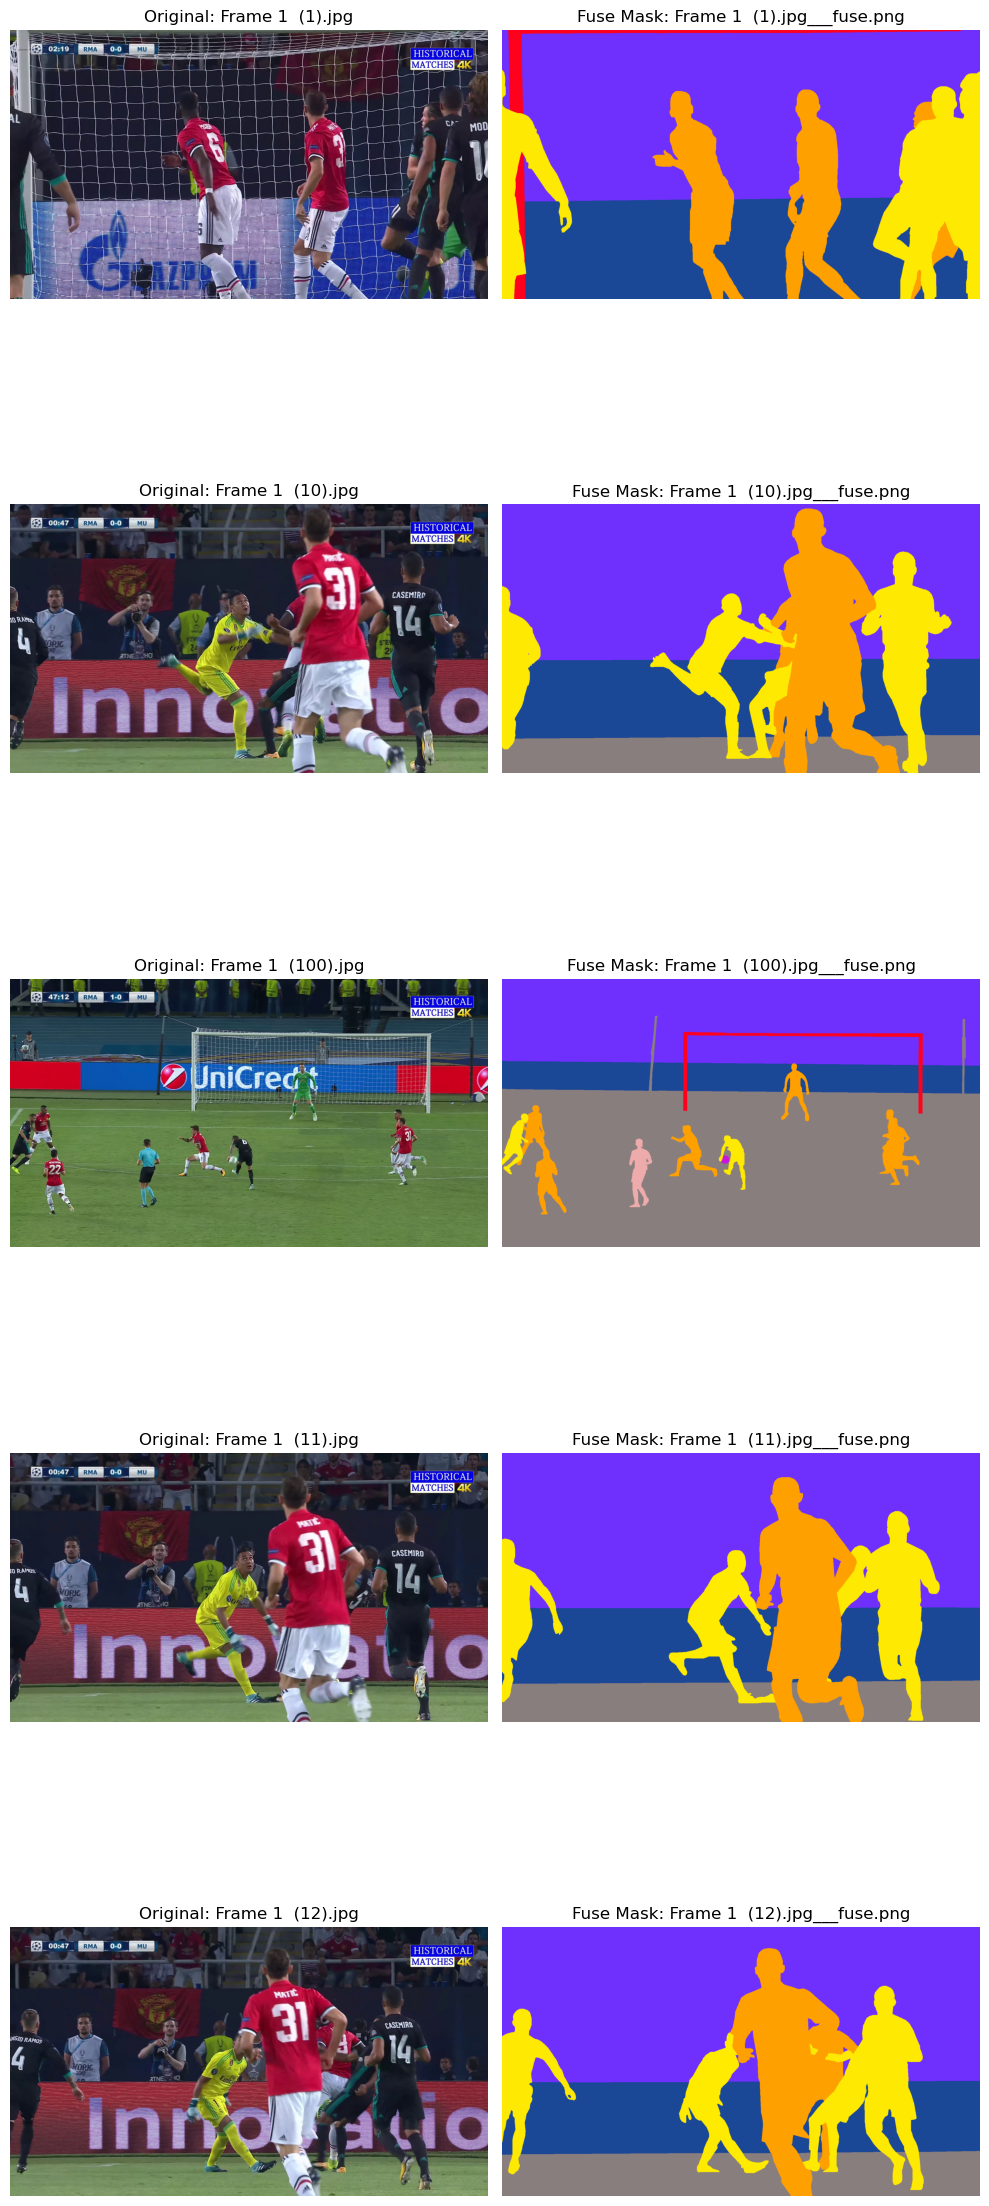

In [ ]:
# 열리면 어떤지 한번 확인해보자

import matplotlib.pyplot as plt

sample_image_pairs = []
num_samples = 5

for orig_file in original_files[:num_samples]:
    base_name = orig_file.replace(".jpg", "")
    fuse_file = next((f for f in fuse_files if base_name in f), None)

    if fuse_file:
        sample_image_pairs.append((orig_file, fuse_file))

# 이미지 5쌍 시각화
fig, axes = plt.subplots(num_samples, 2, figsize=(10, 5 * num_samples))

for i, (orig_file, fuse_file) in enumerate(sample_image_pairs):
    # 이미지 로드
    orig_img = cv2.imread(os.path.join(image_folder, orig_file))
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)  # OpenCV BGR → RGB 변환

    fuse_img = cv2.imread(os.path.join(image_folder, fuse_file))
    fuse_img = cv2.cvtColor(fuse_img, cv2.COLOR_BGR2RGB)  # 마스크도 RGB 변환

    # 시각화
    axes[i, 0].imshow(orig_img)
    axes[i, 0].set_title(f"Original: {orig_file}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(fuse_img)
    axes[i, 1].set_title(f"Fuse Mask: {fuse_file}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

# 3. 전처리 및 파이프라인 구축

## 3.1 PyTorch Dataset 클래스 만들기

In [ ]:
import numpy as np

# 데이터셋 전체의 고유한 색상을 수집하여 클래스 번호(label)와 매핑합니다.
def get_unique_colors(image_folder, mask_files, max_classes=11):
    color_set = set()
    # 모든 마스크 파일을 순회하며 존재하는 모든 색상(RGB 값)을 수집합니다.
    for mask_file in mask_files:
        mask_path = os.path.join(image_folder, mask_file)
        mask = cv2.imread(mask_path, cv2.IMREAD_COLOR)
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        # 이미지를 (픽셀 수, 3) 형태로 바꿔 고유한 RGB 색상 값을 찾습니다.
        unique_colors = np.unique(mask.reshape(-1, 3), axis=0)

        for color in unique_colors:
            color_set.add(tuple(color)) # set에 추가해 중복을 제거합니다. 고유한 색상 저장

    return list(color_set)

unique_colors = get_unique_colors(image_folder, fuse_files, max_classes=11)
color_to_label = {color: idx for idx, color in enumerate(unique_colors)}

print(f"총 {len(color_to_label)}개의 고유 클래스(색상)를 발견했습니다.")

총 11개의 고유 클래스(색상)를 발견했습니다.


In [ ]:
#예전 고양이와 개였다면, Dataset을 이렇게 복잡하게 만들어줄필요없음.
#다만, 여기서는 같은 잔디라도 달라질 수 있기에 이를 만들어주기위해 다음과 같은 것을 해줌.

import torch
from torch.utils.data import Dataset

class FootballDataset(Dataset):
    def __init__(self, image_files, mask_files, image_folder, color_to_label, transforms=None):
        self.image_files = image_files
        self.mask_files = mask_files
        self.image_folder = image_folder
        self.color_to_label = color_to_label
        self.transform = transform

    # 데이터셋의 총 이미지 개수를 알려주는 함수
    def __len__(self):
        return len(self.image_files)

    # idx번째 데이터를 요청받으면 처리해서 반환하는 함수
    def __getitem__(self, idx):
        # 1. 이미지와 마스크 경로 설정
        img_path = os.path.join(self.image_folder, self.image_files[idx])
        mask_path = os.path.join(self.image_folder, self.mask_files[idx])

        # 2. 이미지 불러오기 및 가공
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (256, 256)) / 255.0 # 크기 통일 및 0~1 정규화

        # 3. 마스크 불러오기 및 가공
        mask = cv2.imread(mask_path, cv2.IMREAD_COLOR)
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)

        # 4. 마스크를 클래스 번호가 적힌 맵으로 변환
        mask_class = np.zeros(mask.shape[:2], dtype=np.uint8)
        for color, label in self.color_to_label.items():
            mask_class[(mask == color).all(axis=-1)] = label

        # 5. PyTorch 텐서로 최종 변환
        img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)
        mask = torch.tensor(mask_class, dtype=torch.long)

        return img, mask

- 사진의 색깔을 분류해서, 정답표를 만드는 것. 데이터 가공

## 3.2 데이터 분할

데이터 분할 (Split): 전체 데이터셋을 학습용(train)과 테스트용(test)으로 나눔

In [ ]:
from torch.utils.data import DataLoader, random_split

# 1. 이전에 정의한 변수들을 사용하여 전체 데이터셋 객체를 생성합니다.
dataset = FootballDataset(original_files, fuse_files, image_folder, color_to_label)

# 2. 데이터셋을 학습용(80%)과 테스트용(20%)으로 분리합니다.
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, drop_last=False)

# 4. 모델링 및 학습 (Modeling & Training)

In [ ]:
# U-Net 모델 정의 (BatchNorm 추가) -> Baseline 참조
class UNet(nn.Module):
    def __init__(self, num_classes=11):
        super(UNet, self).__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),  # BatchNorm 추가
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),  # BatchNorm 추가
                nn.ReLU(inplace=True),
            )

        self.encoder1 = conv_block(3, 64)
        self.encoder2 = conv_block(64, 128)
        self.encoder3 = conv_block(128, 256)

        self.pool = nn.MaxPool2d(2, 2)

        self.bottleneck = conv_block(256, 512)

        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.decoder3 = conv_block(512, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.decoder2 = conv_block(256, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder1 = conv_block(128, 64)

        self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.encoder1(x)
        e2 = self.encoder2(self.pool(e1))
        e3 = self.encoder3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.upconv3(b)
        d3 = torch.cat((d3, e3), dim=1)
        d3 = self.decoder3(d3)

        d2 = self.upconv2(d3)
        d2 = torch.cat((d2, e2), dim=1)
        d2 = self.decoder2(d2)

        d1 = self.upconv1(d2)
        d1 = torch.cat((d1, e1), dim=1)
        d1 = self.decoder1(d1)

        return self.final_conv(d1)  # logits 출력

In [ ]:
import torch.optim as optim
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 이전에 설정한 device(GPU 또는 CPU)로 모델을 보냅니다.
model = UNet(num_classes=11).to(device)
# 2. 손실 함수(채점관)를 정의합니다. -> 다중 클래스 분류 문제 CrossEntropyLoss.
criterion = nn.CrossEntropyLoss()
# lr(learning rate)은 학습의 보폭 크기를 의미하며, 0.005는 일반적인 초기값입니다.
optimizer = optim.Adam(model.parameters(), lr=0.004, weight_decay=1e-4)

print(f"모델은 현재 '{device}'")

모델은 현재 'cpu'


In [ ]:
from tqdm import tqdm

# 훈련을 시작!
num_epochs = 50
for epoch in range(num_epochs):
    model.train() # 모델을 '훈련 모드'로 설정합니다.
    epoch_loss = 0 # 이번 epoch의 총 오차를 기록할 변수
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    # train_loader에서 배치(8개 이미지 묶음)를 하나씩 꺼내옵니다.
    for images, masks in progress_bar:
        # 데이터와 마스크를 GPU로 보냅니다.
        images, masks = images.to(device), masks.to(device)
        masks = torch.clamp(masks, min=0, max=10)
        optimizer.zero_grad() # 이전 배치의 기울기(gradient)를 초기화
        outputs = model(images) # 모델에 이미지를 넣음
        loss = criterion(outputs, masks)   # 3. 예측 결과와 실제 마스크를 비교해 오차를 계산.
        loss.backward()         # 4. 오차를 역전파하여 각 파라미터의 기울기를 계산.
        optimizer.step()         # 5. 계산된 기울기를 바탕으로 파라미터를 업데이트.
        epoch_loss += loss.item()         # 현재 배치의 오차를 epoch_loss에 더해줌.

        current_avg_loss = epoch_loss / len(progress_bar)
        progress_bar.set_postfix(loss=f"{current_avg_loss:.4f}")
    # 이번 epoch의 평균 오차를 계산하여 출력합니다.
    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

print("\n훈련이 완료되었습니다!")

Epoch 1/50: 100%|████████████████████████████████████████████████████████████████████████| 10/10 [00:45<00:00,  4.58s/it, loss=1.2118]


Epoch [1/50], Loss: 1.2118


Epoch 2/50: 100%|████████████████████████████████████████████████████████████████████████| 10/10 [00:43<00:00,  4.33s/it, loss=0.7127]


Epoch [2/50], Loss: 0.7127


Epoch 3/50: 100%|████████████████████████████████████████████████████████████████████████| 10/10 [00:46<00:00,  4.65s/it, loss=0.6094]


...

Epoch [38/50], Loss: 0.2419


Epoch 39/50: 100%|███████████████████████████████████████████████████████████████████████| 10/10 [00:42<00:00,  4.28s/it, loss=0.2207]


Epoch [39/50], Loss: 0.2207


Epoch 40/50:   0%|                                                                                             | 0/10 [00:01<?, ?it/s]


KeyboardInterrupt: 

# 5. 결과 시각화

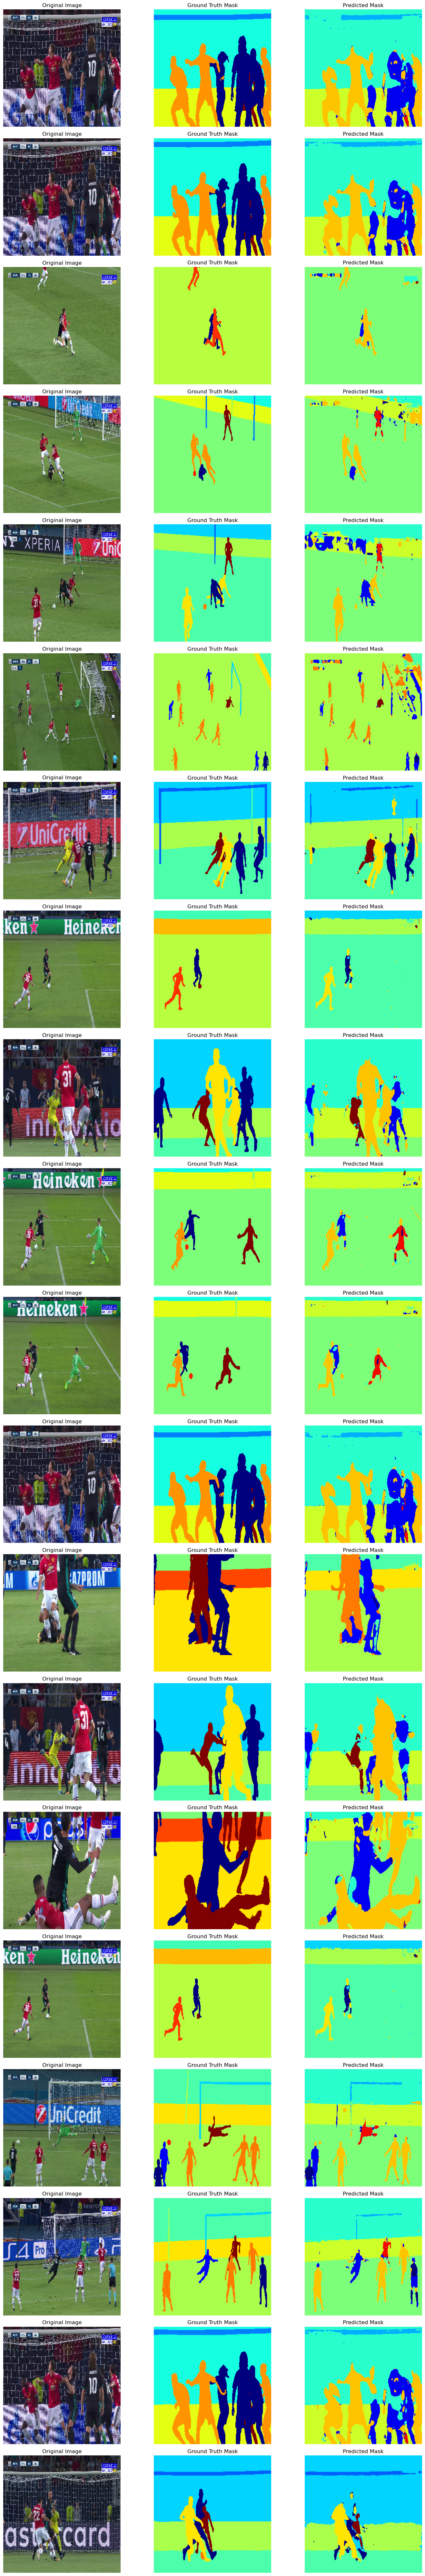

In [ ]:
# 시각화를 위해 matplotlib.pyplot을 다시 불러옵니다.
import matplotlib.pyplot as plt

model.eval()

# with torch.no_grad(): 블록 안에서는 기울기(gradient) 계산을 하지 않아,
# 메모리 사용량이 줄고 계산 속도가 빨라집니다. 평가 시에는 필수적입니다.
with torch.no_grad():
    # 테스트 데이터 로더에서 딱 한 배치만 가져옵니다.
    # test_loader의 batch_size가 4이었으므로, 이미지 4개와 마스크 4개를 가져옵니다.
    images, masks = next(iter(test_loader))

    # 데이터를 GPU로 보냅니다.
    images = images.to(device)

    # 모델에 이미지를 넣어 예측을 수행합니다.
    outputs = model(images)

    # 모델의 출력(outputs)은 각 픽셀별 클래스 점수입니다.
    # torch.argmax를 사용해 가장 점수가 높은 클래스 번호를 선택하여 최종 예측 마스크를 만듭니다.
    pred_masks = torch.argmax(outputs, dim=1).cpu()

    # 시각화를 위해 텐서(Tensor)를 넘파이 배열(Numpy array)로 변환하고,
    # 이미지 채널 순서를 (C, H, W)에서 (H, W, C)로 다시 변경합니다.
    image_to_show = images[0].cpu().permute(1, 2, 0).numpy()
    true_mask_to_show = masks[0].cpu().numpy()
    pred_mask_to_show = pred_masks[0].numpy()

with torch.no_grad():
    test_iter = iter(test_loader)
    plt.figure(figsize=(15, 80))

    plot_index = 1
    for images, masks in test_iter:
        images = images.to(device)
        outputs = model(images)
        pred_masks = torch.argmax(torch.softmax(outputs, dim=1), dim=1).cpu().numpy()

        for b in range(images.size(0)):
            plt.subplot(20, 3, plot_index)
            plt.imshow(images[b].cpu().permute(1, 2, 0))
            plt.title("Original Image")
            plt.axis("off")
            plot_index += 1

            plt.subplot(20, 3, plot_index)
            plt.imshow(masks[b].cpu().numpy(), cmap="jet")
            plt.title("Ground Truth Mask")
            plt.axis("off")
            plot_index += 1

            plt.subplot(20, 3, plot_index)
            plt.imshow(pred_masks[b], cmap="jet")
            plt.title("Predicted Mask")
            plt.axis("off")
            plot_index += 1

            if plot_index > 20 * 3:  # 20개 이미지까지 시각화
                break
        if plot_index > 20 * 3:
            break

    plt.tight_layout()
    plt.show()


In [ ]:
from tqdm import tqdm
import torch

# mIoU 점수를 계산하는 함수
def calculate_miou(model, data_loader, device, num_classes=11):
    model.eval() # 모델을 '평가 모드'로 설정합니다.

    # 각 클래스별 교집합(intersection)과 합집합(union)의 총합을 저장할 변수
    total_intersection = torch.zeros(num_classes, device=device)
    total_union = torch.zeros(num_classes, device=device)

    # 평가 시에는 그래디언트 계산이 필요 없으므로, torch.no_grad()를 사용합니다.
    with torch.no_grad():
        for images, masks in tqdm(data_loader, desc="Calculating mIoU"):
            images, masks = images.to(device), masks.to(device)

            # 모델 예측
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            # 각 클래스(0부터 10까지)에 대해 교집합과 합집합을 계산
            for cls in range(num_classes):
                pred_inds = (preds == cls)
                target_inds = (masks == cls)

                intersection = (pred_inds & target_inds).sum() # AND 연산: 둘 다 True인 픽셀
                union = (pred_inds | target_inds).sum()      # OR 연산: 둘 중 하나라도 True인 픽셀

                total_intersection[cls] += intersection
                total_union[cls] += union

    # 각 클래스별 IoU 계산 (0으로 나누는 것을 방지하기 위해 작은 값(1e-6)을 더함)
    iou = total_intersection / (total_union + 1e-6)

    # 모든 클래스의 IoU 평균(mIoU)을 계산하여 최종 점수로 반환
    miou = iou.mean()
    return miou.item() # 파이썬 숫자로 변환하여 반환

In [ ]:
# test_loader와 이전에 학습된 model을 사용하여 mIoU를 계산합니다.
test_miou = calculate_miou(model, test_loader, device, num_classes=11)

print(f"\n##################################")
print(f"## 최종 모델 성능 (mIoU): {test_miou:.4f} ##")
print(f"##################################")

Calculating mIoU: 100%|███████████████████████████████████████████████████████████████████████████████| 20/20 [00:05<00:00,  3.87it/s]


##################################
## 최종 모델 성능 (mIoU): 0.5407 ##
##################################


- Baseline 성능지표 = 0.3648 (Epoch = 10)
- 1차 업데이트 이후 (하이퍼 파라미터 최적화) = 0.3118 (Epoch = 10) ?
    - 더 떨어짐..? 좀 이상함.
- 2차 업데이트 (입력값을 Save에서 Fuse로 교환 및 11개 색깔 최적화) = 0.4653
- 3차 업데이트 (데이터 증강 및 Epoch 수를 10에서 50으로 늘림) = 0.5407 (Epoch = 50)

# 6. 업데이트

## 1) 하이퍼 파라미터 최적화

In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [optuna]━━━━ 1/2 [optuna]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import optuna
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim

def objective(trial):
    """Optuna가 하이퍼파라미터를 바꿔가며 호출할 함수"""
    # --- 하이퍼파라미터 탐색 공간 정의 ---

    # 1. 학습률(lr): 1e-5 ~ 1e-2 사이에서 로그 스케일로 값을 제안받음
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    # 2. 가중치 감쇠(weight_decay): 1e-5 ~ 1e-3 사이에서 값을 제안받음
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)

    # --- 모델, 옵티마이저, 손실 함수 설정 ---
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = UNet(num_classes=11).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    # --- 모델 훈련 (튜닝 시간을 위해 Epoch 수를 줄여서 진행) ---
    num_epochs = 15
    for epoch in range(num_epochs):
        model.train()
        for images, masks in train_loader: # tqdm은 여기서는 생략하여 로그를 깔끔하게 유지
            images, masks = images.to(device), masks.to(device)
            masks = torch.clamp(masks, min=0, max=10)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

    # --- 모델 평가 --- (calculate_miou 함수는 이전에 정의되어 있어야 합니다)
    final_miou = calculate_miou(model, test_loader, device, num_classes=11)

    # --- 최종 점수(mIoU) 반환 --- # Optuna는 이 반환값을 보고 점수가 높은 쪽으로 탐색을 계속합니다.
    return final_miou

# ===================================================================
# 2. Optuna 탐색(Study) 생성 및 실행
# ===================================================================
# 'direction="maximize"'는 objective 함수가 반환하는 값(mIoU)을 최대화.
study = optuna.create_study(direction="maximize")

# n번의 다른 하이퍼파라미터 조합으로 실험.
study.optimize(objective, n_trials=20)


# ===================================================================
# 3. 최종 결과 확인
# ===================================================================
print("\n##################################")
print("## Optuna 탐색이 완료되었습니다! ##")
print("##################################")
print(f"총 시도 횟수: {len(study.trials)}")
print(f"최고 mIoU 점수: {study.best_value:.4f}")
print("최적의 하이퍼파라미터:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value:4f}")

- lr: 0.00421875
- weight_decay: 0.00015892

## 2) 데이터 증강

In [ ]:
import os
import cv2

# 폴더 내 모든 파일 목록 가져오기
file_list = os.listdir(image_folder)

# 원본 이미지(.jpg)와 fuse 이미지 매칭
original_files = sorted([f for f in file_list if f.endswith(".jpg")])
fuse_files = sorted([f for f in file_list if "save" in f]) # fuse를 save로 변경 (모두 변경하기엔 까다로울 수 있음으로)

# 이미지 로드 및 확인
image_pairs = []
for orig_file in original_files:
    # 동일한 프레임의 fuse 파일 찾기
    base_name = orig_file.replace(".jpg", "")
    fuse_file = next((f for f in fuse_files if base_name in f), None)

    if fuse_file:
        # 원본과 마스크 로드
        img_path = os.path.join(image_folder, orig_file)
        mask_path = os.path.join(image_folder, fuse_file)

        img = cv2.imread(img_path)
        mask = cv2.imread(mask_path)

        if img is not None and mask is not None:
            image_pairs.append((img, mask))

# 최종적으로 로드된 이미지 쌍 개수 출력
print(f"{len(image_pairs)} pairs")

100 pairs


In [ ]:
!pip install -U albumentations

import albumentations as A
from albumentations.pytorch import ToTensorV2 # Numpy -> Tensor 변환

# 훈련(Train)용 transform: 데이터 증강 포함
train_transform = A.Compose([
    A.Resize(256, 256),              # 1. 크기 조절
    A.HorizontalFlip(p=0.5),         # 2. 50% 확률로 좌우 반전
    A.ColorJitter(p=0.5),            # 3. 50% 확률로 색상 변경
    A.Normalize(mean=(0, 0, 0), std=(1, 1, 1)), # 4. 0~1 정규화 (img/255.0과 동일)
    # ToTensorV2() # -> Dataset에서 직접 텐서로 변환하므로 여기선 주석 처리
])

# 테스트(Test)용 transform: 데이터 증강 없음 (크기 조절과 정규화만)
test_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0, 0, 0), std=(1, 1, 1)),
    # ToTensorV2()
])

In [ ]:
class CustomDataset(Dataset):
    # 클래스가 처음 생성될 때 실행되는 초기화 함수
    def __init__(self, img_path, mask_path, mapping_dict, transform=None):
        self.image_paths = image_paths    # 이미지 경로 리스트
        self.mask_paths = mask_paths      # 마스크 경로 리스트
        self.mapping_dict = mapping_dict  # 우리가 만든 ID 변환기 (핵심 부품)
        self.transform = transform        # 이미지에 적용할 변환

    # 데이터셋의 총 길이를 반환하는 함수
    def __len__(self):
        return len(self.image_paths)

    # 특정 인덱스(idx)의 데이터를 요청받았을 때 실행되는 함수
    def __getitem__(self, idx):
        # 1. 파일 열기
        image = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx])
        mask_array = np.array(mask)

        # 2. 핵심 기능: Instance 마스크를 Semantic 마스크로 변환
        semantic_mask = convert_mask(mask_array, self.mapping_dict)

        # 3. 데이터 증강 등 변환 적용
        if self.transform:
            semantic_mask_pil = Image.fromarray(semantic_mask)
            image = self.transform(image)
            # 마스크는 텐서로만 변환
            mask_transform = T.Compose([T.ToTensor()])
            semantic_mask = mask_transform(semantic_mask_pil)

        # 4. 최종 결과 반환
        return image, semantic_mask

In [ ]:
from scipy.spatial import KDTree # 가장 가까운 점을 빠르게 찾기 위한 라이브러리

class FootballDataset(Dataset):
    def __init__(self, image_files, mask_files, image_folder, color_map, transform=None):
        self.image_files = image_files
        self.mask_files = mask_files
        self.image_folder = image_folder
        self.transform = transform

        # 대표 색상들로 KDTree를 만들어 빠른 검색을 준비합니다.
        self.color_map_list = list(color_map.keys())
        self.color_map_kdtree = KDTree(self.color_map_list)
        self.label_map = {color: label for color, label in color_map.items()}

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_folder, self.image_files[idx])
        mask_path = os.path.join(self.image_folder, self.mask_files[idx])
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.cvtColor(cv2.imread(mask_path, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

        # (이 부분은 albumentations를 사용할 경우에만 해당)
        if self.transform:
            transformed = self.transform(image=img, mask=mask)
            img = transformed['image']
            mask = transformed['mask']

        # --- ✨ 여기가 바로 최종 해결책입니다 ✨ ---
        # 1. 마스크의 픽셀들을 (너비*높이, 3) 형태로 펼칩니다.
        pixels = mask.reshape(-1, 3)
        # 2. KDTree를 사용해 각 픽셀과 가장 가까운 대표 색상을 한번에 찾습니다.
        distances, indices = self.color_map_kdtree.query(pixels)
        # 3. 찾은 인덱스를 사용해 각 픽셀에 대한 클래스 번호를 할당합니다.
        mask_class = np.array([self.label_map[self.color_map_list[i]] for i in indices])
        # 4. 원래 마스크 모양(높이, 너비)으로 복원합니다.
        mask_class = mask_class.reshape(mask.shape[:2]).astype(np.uint8)

        # 5. PyTorch 텐서로 변환
        img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) if not self.transform else img
        mask_tensor = torch.tensor(mask_class, dtype=torch.long)

        return img, mask_tensor

In [ ]:
from torch.utils.data import DataLoader, random_split

# 1. 이전에 정의한 변수들을 사용하여 전체 데이터셋 객체를 생성합니다.
dataset = FootballDataset(original_files, fuse_files, image_folder, color_to_label, train_transform)

# 2. 데이터셋을 학습용(80%)과 테스트용(20%)으로 분리합니다.
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

# 7. 성능 평가 및 최종 제출 (Performance Evaluation & Submission)

1. 프로젝트 목표

- Semantic Segmentation: 이미지 내 모든 픽셀을 특정 클래스로 분류
- 핵심 전략: 대용량 데이터 처리를 위한 딥러닝 파이프라인 최적화

2. 데이터 처리

- 데이터셋: PyTorch Dataset 클래스를 활용한 커스텀 데이터셋 구축
- 효과: 전체 학습 효율성 증대

3. 모델링 및 평가

- 모델: U-Net - 검증된 Segmentation 아키텍처 활용
- 학습: 데이터 증강(Data Augmentation)으로 모델 일반화 성능 향상
- 평가: mIoU(mean Intersection over Union) 지표로 성능 검증 완료

4. 결론

- 성과: 효율적인 데이터 처리 기반 위에서 Semantic Segmentation 과제를 U-Net을 이용하여, 과제를 완수
- 다음엔 팀원들과 같이 U-Net뿐아니라 이와 비슷한 것들을 함께해서 비교하는 것이 조금 더 좋을 수 있다.

# 멘토평

체계적이고 실험적인 접근 방식을 보여주며, 특히 데이터 분석과 하이퍼파라미터 최적화에서 탁월한 역량을 발휘했습니다. 6단계 프로세스(미션 정의 및 환경설정, 데이터 탐색 및 분석, 전처리 및 데이터 파이프라인 구축, 모델링 및 학습, 결과 시각화, 성능 평가 및 최종 제출)를 명확히 정의하고, U-Net을 이용한 축구 경기 영상 Semantic Segmentation이라는 구체적인 목표를 수립했습니다. UEFA 슈퍼컵 2017 데이터셋의 11개 클래스를 픽셀 단위로 분류하는 작업을 체계적으로 수행했으며, 실제로 Baseline 대비 48%의 성능 개선(0.3648 → 0.5407)을 달성한 점이 매우 인상적입니다.

주요 강점으로는 체계적인 6단계 프로세스 정의, Fuse와 Save 마스크의 비교 분석 및 논리적 선택, Optuna를 활용한 하이퍼파라미터 자동 튜닝을 들 수 있습니다. Fuse와 Save의 고유 색상을 tqdm을 활용하여 전체 마스크 파일에서 스캔하고 분석한 결과, "Fuse에서 발견할 수 있는 색상은 11가지이며, 같은 사물은 같은 색상끼리 나누어져있기에, Fuse를 사용"한다는 명확한 선택 근거를 제시했습니다. scipy.spatial.KDTree를 활용하여 빠른 색상 매칭을 구현하고, 픽셀별로 가장 가까운 대표 색상을 검색하는 최적화 기법이 돋보입니다. Optuna를 통해 20회 시도로 학습률(1e-5 ~ 1e-2, log scale)과 weight_decay(1e-5 ~ 1e-3, log scale)의 최적값(lr=0.00421875, weight_decay=0.00015892)을 발견했습니다.

성능 향상 과정을 단계별로 명확히 기록한 점이 특히 우수합니다. Baseline에서 0.3648(Epoch=10)를 기록한 후, Save에서 Fuse로 전환하며 0.4653으로 개선했고, 데이터 증강(HorizontalFlip, ColorJitter)과 Epoch 50 적용으로 최종 0.5407을 달성했습니다. get_unique_colors(), calculate_miou(), objective() 등의 함수를 체계적으로 구현했고, U-Net 구조(Encoder 3단계: 64→128→256, Bottleneck: 512, Decoder 3단계 with skip connection)를 명확히 설계했습니다. mIoU(Mean Intersection over Union)를 평가 지표로 사용하여 클래스별 교집합/합집합을 계산하고, 0으로 나누기 방지(1e-6)와 AND/OR 연산으로 정확한 계산을 수행했습니다. 미션 가이드 형식의 매우 상세한 문서화, 클래스 목록의 표 형식 정리, 성능 개선 팁(Data Augmentation, Hyperparameter Tuning, Model Architecture 변경) 명시도 훌륭합니다.  

향후 발전을 위해서는 몇 가지 보완이 필요합니다. 코드 주석을 보강하여 복잡한 로직의 이해를 돕고, 주석 처리된 코드를 정리하여 가독성을 높여야 합니다. 예측 마스크와 실제 마스크의 비교 시각화, Optuna 탐색 결과의 시각화, 최종 모델의 클래스별 IoU 분석을 추가한다면 연구의 완성도를 크게 높일 수 있습니다. 일부 코드 중복을 제거하고 모듈화를 강화한다면 유지보수성을 더욱 개선할 수 있습니다. 전반적으로 체계적인 실험 설계와 정량적 성능 개선 달성, 자동화된 하이퍼파라미터 최적화가 매우 우수한 프로젝트이며, 시각화와 코드 품질 측면을 보완한다면 학술적 가치까지 갖춘 완성도 높은 연구가 될 것입니다.